<a href="https://colab.research.google.com/github/atharva508/CricketMonteCarlo/blob/main/Copy_of_EEE_598_Lab_5_CNN_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN - UNet, Multi-GPU, Custom Augmentation, Feature Visualization,

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
import torch.utils.data as data
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import itertools

import torchsummary

## List of Available Model in TorchVision

In [ ]:
# To show all model in Pytorch
models.list_models()

['alexnet',
 'convnext_base',
 'convnext_large',
 'convnext_small',
 'convnext_tiny',
 'deeplabv3_mobilenet_v3_large',
 'deeplabv3_resnet101',
 'deeplabv3_resnet50',
 'densenet121',
 'densenet161',
 'densenet169',
 'densenet201',
 'efficientnet_b0',
 'efficientnet_b1',
 'efficientnet_b2',
 'efficientnet_b3',
 'efficientnet_b4',
 'efficientnet_b5',
 'efficientnet_b6',
 'efficientnet_b7',
 'efficientnet_v2_l',
 'efficientnet_v2_m',
 'efficientnet_v2_s',
 'fasterrcnn_mobilenet_v3_large_320_fpn',
 'fasterrcnn_mobilenet_v3_large_fpn',
 'fasterrcnn_resnet50_fpn',
 'fasterrcnn_resnet50_fpn_v2',
 'fcn_resnet101',
 'fcn_resnet50',
 'fcos_resnet50_fpn',
 'googlenet',
 'inception_v3',
 'keypointrcnn_resnet50_fpn',
 'lraspp_mobilenet_v3_large',
 'maskrcnn_resnet50_fpn',
 'maskrcnn_resnet50_fpn_v2',
 'maxvit_t',
 'mc3_18',
 'mnasnet0_5',
 'mnasnet0_75',
 'mnasnet1_0',
 'mnasnet1_3',
 'mobilenet_v2',
 'mobilenet_v3_large',
 'mobilenet_v3_small',
 'mvit_v1_b',
 'mvit_v2_s',
 'quantized_googlenet',
 '

In [ ]:
# import torchvision.models as models

# Get lists of model names using models.list_models
classification_models = models.list_models(module=models)
segmentation_models = models.list_models(module=models.segmentation)
detection_models = models.list_models(module=models.detection)
video_models = models.list_models(module=models.video)

# Print the lists
display("Classification models:", classification_models)
display("Segmentation models:", segmentation_models)
display("Detection models:", detection_models)
display("Video models:", video_models)

'Classification models:'

['alexnet',
 'convnext_base',
 'convnext_large',
 'convnext_small',
 'convnext_tiny',
 'densenet121',
 'densenet161',
 'densenet169',
 'densenet201',
 'efficientnet_b0',
 'efficientnet_b1',
 'efficientnet_b2',
 'efficientnet_b3',
 'efficientnet_b4',
 'efficientnet_b5',
 'efficientnet_b6',
 'efficientnet_b7',
 'efficientnet_v2_l',
 'efficientnet_v2_m',
 'efficientnet_v2_s',
 'googlenet',
 'inception_v3',
 'maxvit_t',
 'mnasnet0_5',
 'mnasnet0_75',
 'mnasnet1_0',
 'mnasnet1_3',
 'mobilenet_v2',
 'mobilenet_v3_large',
 'mobilenet_v3_small',
 'regnet_x_16gf',
 'regnet_x_1_6gf',
 'regnet_x_32gf',
 'regnet_x_3_2gf',
 'regnet_x_400mf',
 'regnet_x_800mf',
 'regnet_x_8gf',
 'regnet_y_128gf',
 'regnet_y_16gf',
 'regnet_y_1_6gf',
 'regnet_y_32gf',
 'regnet_y_3_2gf',
 'regnet_y_400mf',
 'regnet_y_800mf',
 'regnet_y_8gf',
 'resnet101',
 'resnet152',
 'resnet18',
 'resnet34',
 'resnet50',
 'resnext101_32x8d',
 'resnext101_64x4d',
 'resnext50_32x4d',
 'shufflenet_v2_x0_5',
 'shufflenet_v2_x1_0',
 'sh

'Segmentation models:'

['deeplabv3_mobilenet_v3_large',
 'deeplabv3_resnet101',
 'deeplabv3_resnet50',
 'fcn_resnet101',
 'fcn_resnet50',
 'lraspp_mobilenet_v3_large']

'Detection models:'

['fasterrcnn_mobilenet_v3_large_320_fpn',
 'fasterrcnn_mobilenet_v3_large_fpn',
 'fasterrcnn_resnet50_fpn',
 'fasterrcnn_resnet50_fpn_v2',
 'fcos_resnet50_fpn',
 'keypointrcnn_resnet50_fpn',
 'maskrcnn_resnet50_fpn',
 'maskrcnn_resnet50_fpn_v2',
 'retinanet_resnet50_fpn',
 'retinanet_resnet50_fpn_v2',
 'ssd300_vgg16',
 'ssdlite320_mobilenet_v3_large']

'Video models:'

['mc3_18',
 'mvit_v1_b',
 'mvit_v2_s',
 'r2plus1d_18',
 'r3d_18',
 's3d',
 'swin3d_b',
 'swin3d_s',
 'swin3d_t']

## Load Different Model from Different Modalities

In [ ]:
import torch
from torchvision import models

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load models from different modalities
classification_model = models.resnet50(pretrained=True).to(device).eval()
segmentation_model = models.segmentation.fcn_resnet50(pretrained=True).to(device).eval()
detection_model = models.detection.fasterrcnn_resnet50_fpn(pretrained=True).to(device).eval()
video_model = models.video.r3d_18(pretrained=True).to(device).eval()

print("Models loaded successfully!")

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FCN_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=FCN_ResNet50_Weights.DEFAULT` to get the mo

Models loaded successfully!


## Model Summary

In [ ]:
import torch
from torchvision import models

# Load the ResNet50 model
classification_model = models.resnet50(pretrained=True)

# Basic model summary
print(classification_model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

## Better way to show model summary

In [ ]:
import torch
from torchvision import models
from torchsummary import summary

# Load the ResNet50 model
classification_model = models.resnet50(pretrained=True)

# Model summary using torchsummary
print("ResNet50 Model Summary with torchsummary:")
S = summary(classification_model, input_size=(3, 224, 224))

ResNet50 Model Summary with torchsummary:
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]           4,096
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]          16,384
      BatchNorm2d-12          [-1, 256, 56, 56]             512
           Conv2d-13          [-1, 256, 56, 56]          16,3

### Manual Way to Get the Parameter Count

In [ ]:
parameters = 0
for p in classification_model.parameters():
    parameters += p.numel()
print(f"Number of parameters: {parameters}")

Number of parameters: 25557032


## Show Classification Inference

### How to Download an Folder from Google Drive?

In [ ]:
!gdown --folder https://drive.google.com/drive/u/2/folders/1yA7x1zjxynrR-dRtgjCj5Dpg30QWkKV0

Retrieving folder contents
Processing file 1Z6NnrFau5-K4rgEj33po5a7p_NasTR5s cat.jpg
Processing file 1UFOuuHDan4ZNaH_Ga92ft13WNilfOuGS cat2.jpg
Processing file 1JTwvoS3hhizSJL04ernY4F8RgmxuQPN- cat3.png
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1Z6NnrFau5-K4rgEj33po5a7p_NasTR5s
To: /content/Imge_samples/cat.jpg
100% 70.1k/70.1k [00:00<00:00, 84.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1UFOuuHDan4ZNaH_Ga92ft13WNilfOuGS
To: /content/Imge_samples/cat2.jpg
100% 159k/159k [00:00<00:00, 8.59MB/s]
Downloading...
From: https://drive.google.com/uc?id=1JTwvoS3hhizSJL04ernY4F8RgmxuQPN-
To: /content/Imge_samples/cat3.png
100% 149k/149k [00:00<00:00, 87.8MB/s]
Download completed


In [ ]:
import torch
from torchvision import models, transforms
from PIL import Image

# Load the pretrained ResNet50 model
model = models.resnet50(pretrained=True).eval() # Let's change it to efficentNet (any variant)

# Preprocess the image
img = Image.open('/content/Imge_samples/cat.jpg')
# Quiz - Download and upload those images to one folder of your google drive and read the cat.png

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
img_tensor = transform(img).unsqueeze(0)  # Add batch dimension

# Perform inference
output = model(img_tensor)
_, predicted_class = output.max(1)

print(f"Predicted class ID: {predicted_class.item()}")


Predicted class ID: 282


### How can we show the labels of the prediction classes?
Hints, resnet50 was trained on ImageNet containing 1000 classes.

## Show Segmentation Model

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


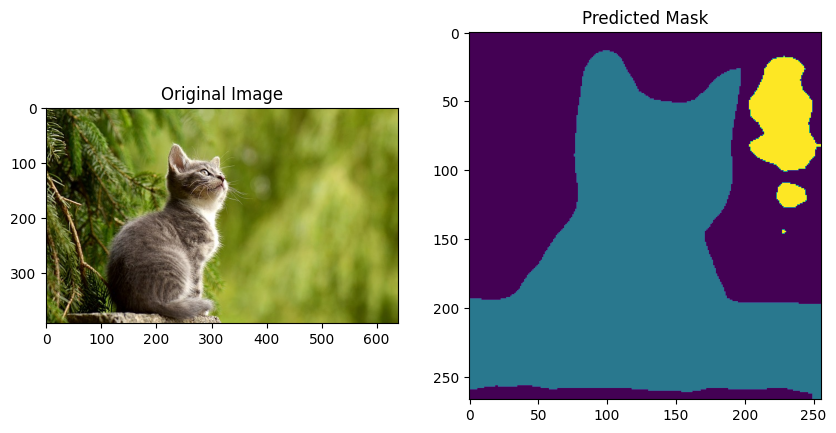

In [ ]:
import torch
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt

model = models.segmentation.deeplabv3_resnet50(pretrained=True).eval()

# Load and preprocess the image
img_tensor = transforms.Compose([
    transforms.Resize(256),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])(Image.open('/content/Imge_samples/cat2.jpg')).unsqueeze(0)

# Perform inference and get the predicted mask
predicted_mask = model(img_tensor)['out'].argmax(1).squeeze().cpu().numpy()

# Display the original image and the segmentation mask
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(Image.open('/content/Imge_samples/cat2.jpg'))
plt.title("Original Image")

plt.subplot(1, 2, 2)
plt.imshow(predicted_mask)
plt.title("Predicted Mask")
plt.show()
